# Definitions

## Imports

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
import json
warnings.filterwarnings('ignore')

## Function Def

In [ ]:
def normalize_dataframe(df, columns_to_normalize):
    """
    Normalize specified columns of a DataFrame column-wise.

    Parameters:
    df (pd.DataFrame): The DataFrame to normalize.
    columns_to_normalize (list): List of column names to normalize.

    Returns:
    pd.DataFrame: A DataFrame with normalized columns.
    """
    drop = []
    mins = []
    maxes = []
    for column in columns_to_normalize:
        mins.append(df[column].min())
        maxes.append(df[column].max())
        
        print(f"{column} min: {df[column].min()}, max: {df[column].max()}")
        if df[column].min() == df[column].max():
            drop.append(column)
        df[column] = (df[column] - df[column].min()) / (df[column].max() - df[column].min())  # add small epsilon to prevent division by zero
        
    df = df.drop(columns=drop)
    print(f"Dropped: {len(drop)} columns \n {drop}")
    print(f"\n Mins = {mins}")
    print(f"\n Maxes = {maxes}")
    return df

    

## Prepating Data

In [ ]:
index_names = ['unit_number', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = ['s_{}'.format(i+1) for i in range(0,21)]
col_names = index_names + setting_names + sensor_names
# for filenum in range(1,2):
filenum = 1
print(f"{filenum}\n\n")
CurrentFile = f"train_FD00{filenum}"
df = pd.read_csv('CMaps/'+ CurrentFile + '.txt',sep='\s+',header=None,index_col=False,names=col_names)
df.drop(columns=['setting_1', 'setting_2', 'setting_3'], inplace=True)
# print(df.iloc[0,:])
df = normalize_dataframe(df, sensor_names)
# print(df.iloc[0,:])
# break
Data = [[] for _ in range(df.iloc[-1,0])]
for i in range(len(df)):
    row = df.iloc[i,2:]
    idx = int(df.iloc[i,0] - 1)
    Data[idx].append(row.tolist())


# with open( 'Data/' + CurrentFile + 'in.json', 'w') as file:
#     json.dump(Data, file)
# file.close()
def all_up(data, n_start=5, n_end=5):
    """
    Automatically flip sensors that decrease with degradation,
    so that all sensors increase with degradation.
    
    Parameters
    ----------
    data : list of units, each unit is list of timesteps, each timestep is list of normalized sensor values
           (all values already in [0,1])
    n_start : int, number of cycles from start to average for baseline
    n_end   : int, number of cycles from end to average for failure
    
    Returns
    -------
    transformed_data : list with same structure as input
    flipped_sensors : list of indices that were flipped
    """
    # Convert all units to np arrays for inspection
    arrays = [np.array(unit, dtype=float) for unit in data if len(unit) > 0]
    if len(arrays) == 0:
        return data, []

    n_sensors = arrays[0].shape[1]
    flipped = []

    for s in range(n_sensors):
        # collect start and end averages across all units
        starts, ends = [], []
        for arr in arrays:
            T = arr.shape[0]
            n0 = min(n_start, T)
            nE = min(n_end, T)
            starts.append(np.mean(arr[:n0, s]))
            ends.append(np.mean(arr[-nE:, s]))
        # average across units
        start_mean = np.mean(starts)
        end_mean = np.mean(ends)
        if end_mean < start_mean:
            flipped.append(s)

    # Now flip decreasing sensors
    transformed = []
    for arr in arrays:
        new_arr = arr.copy()
        new_arr[:, flipped] = 1.0 - new_arr[:, flipped]
        transformed.append(new_arr.tolist())

    return transformed, flipped

# -----------------------------
# Example usage:
# data_diraware, flipped = direction_aware_preprocess(data)
# print("Flipped sensors:", flipped)


1


s_1 min: 518.67, max: 518.67
s_2 min: 641.21, max: 644.53
s_3 min: 1571.04, max: 1616.91
s_4 min: 1382.25, max: 1441.49
s_5 min: 14.62, max: 14.62
s_6 min: 21.6, max: 21.61
s_7 min: 549.85, max: 556.06
s_8 min: 2387.9, max: 2388.56
s_9 min: 9021.73, max: 9244.59
s_10 min: 1.3, max: 1.3
s_11 min: 46.85, max: 48.53
s_12 min: 518.69, max: 523.38
s_13 min: 2387.88, max: 2388.56
s_14 min: 8099.94, max: 8293.72
s_15 min: 8.3249, max: 8.5848
s_16 min: 0.03, max: 0.03
s_17 min: 388, max: 400
s_18 min: 2388, max: 2388
s_19 min: 100.0, max: 100.0
s_20 min: 38.14, max: 39.43
s_21 min: 22.8942, max: 23.6184
Dropped: 6 columns 
 ['s_1', 's_5', 's_10', 's_16', 's_18', 's_19']

 Mins = [np.float64(518.67), np.float64(641.21), np.float64(1571.04), np.float64(1382.25), np.float64(14.62), np.float64(21.6), np.float64(549.85), np.float64(2387.9), np.float64(9021.73), np.float64(1.3), np.float64(46.85), np.float64(518.69), np.float64(2387.88), np.float64(8099.94), np.float64(8.3249), np.float64(0.03),

# Failure Analysis and Stress Testing

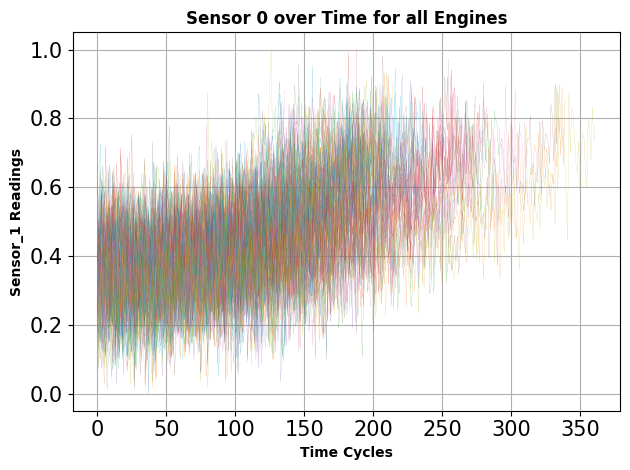

In [52]:
index_names = ['unit_number', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = ['s_{}'.format(i+1) for i in range(0,21)]
col_names = index_names + setting_names + sensor_names
CurrentFile = f"train_FD00{1}"
# df = pd.read_csv('CMaps/'+ CurrentFile + '.txt',sep='\s+',header=None,index_col=False,names=col_names)

n = 0
i = 0 
plt.Figure(dpi=300)
for Engine in Data:
    i += 1
    signal = []
    for flight in Engine:
        signal.append(flight[n])
    plt.plot(signal,  linewidth=0.1, label = f"Engine {i}")
plt.title(f"Sensor {n} over Time for all Engines",fontweight='bold')
plt.xlabel('Time Cycles',fontweight='bold')
plt.xticks(size=15)
plt.ylabel(f'Sensor_{n+1} Readings',fontweight='bold')
plt.yticks(size=15)
plt.grid(True)
plt.tight_layout()
# plt.legend()
plt.show()        

In [ ]:
index_names = ['unit_number', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = ['s_{}'.format(i+1) for i in range(0,21)]
col_names = index_names + setting_names + sensor_names
CurrentFile = f"train_FD00{1}"
# df = pd.read_csv('CMaps/'+ CurrentFile + '.txt',sep='\s+',header=None,index_col=False,names=col_names)

n = 0
i = 0 
plt.Figure(dpi=300)
for Engine in Data:
    i += 1
    signal = []
    for flight in Engine:
        signal.append(flight[n])
    plt.plot(signal,  linewidth=0.1, label = f"Engine {i}")
plt.title(f"Sensor {n} over Time for all Engines",fontweight='bold')
plt.xlabel('Time Cycles',fontweight='bold')
plt.xticks(size=15)
plt.ylabel(f'Sensor_{n+1} Readings',fontweight='bold')
plt.yticks(size=15)
plt.grid(True)
plt.tight_layout()
# plt.legend()
plt.show()        

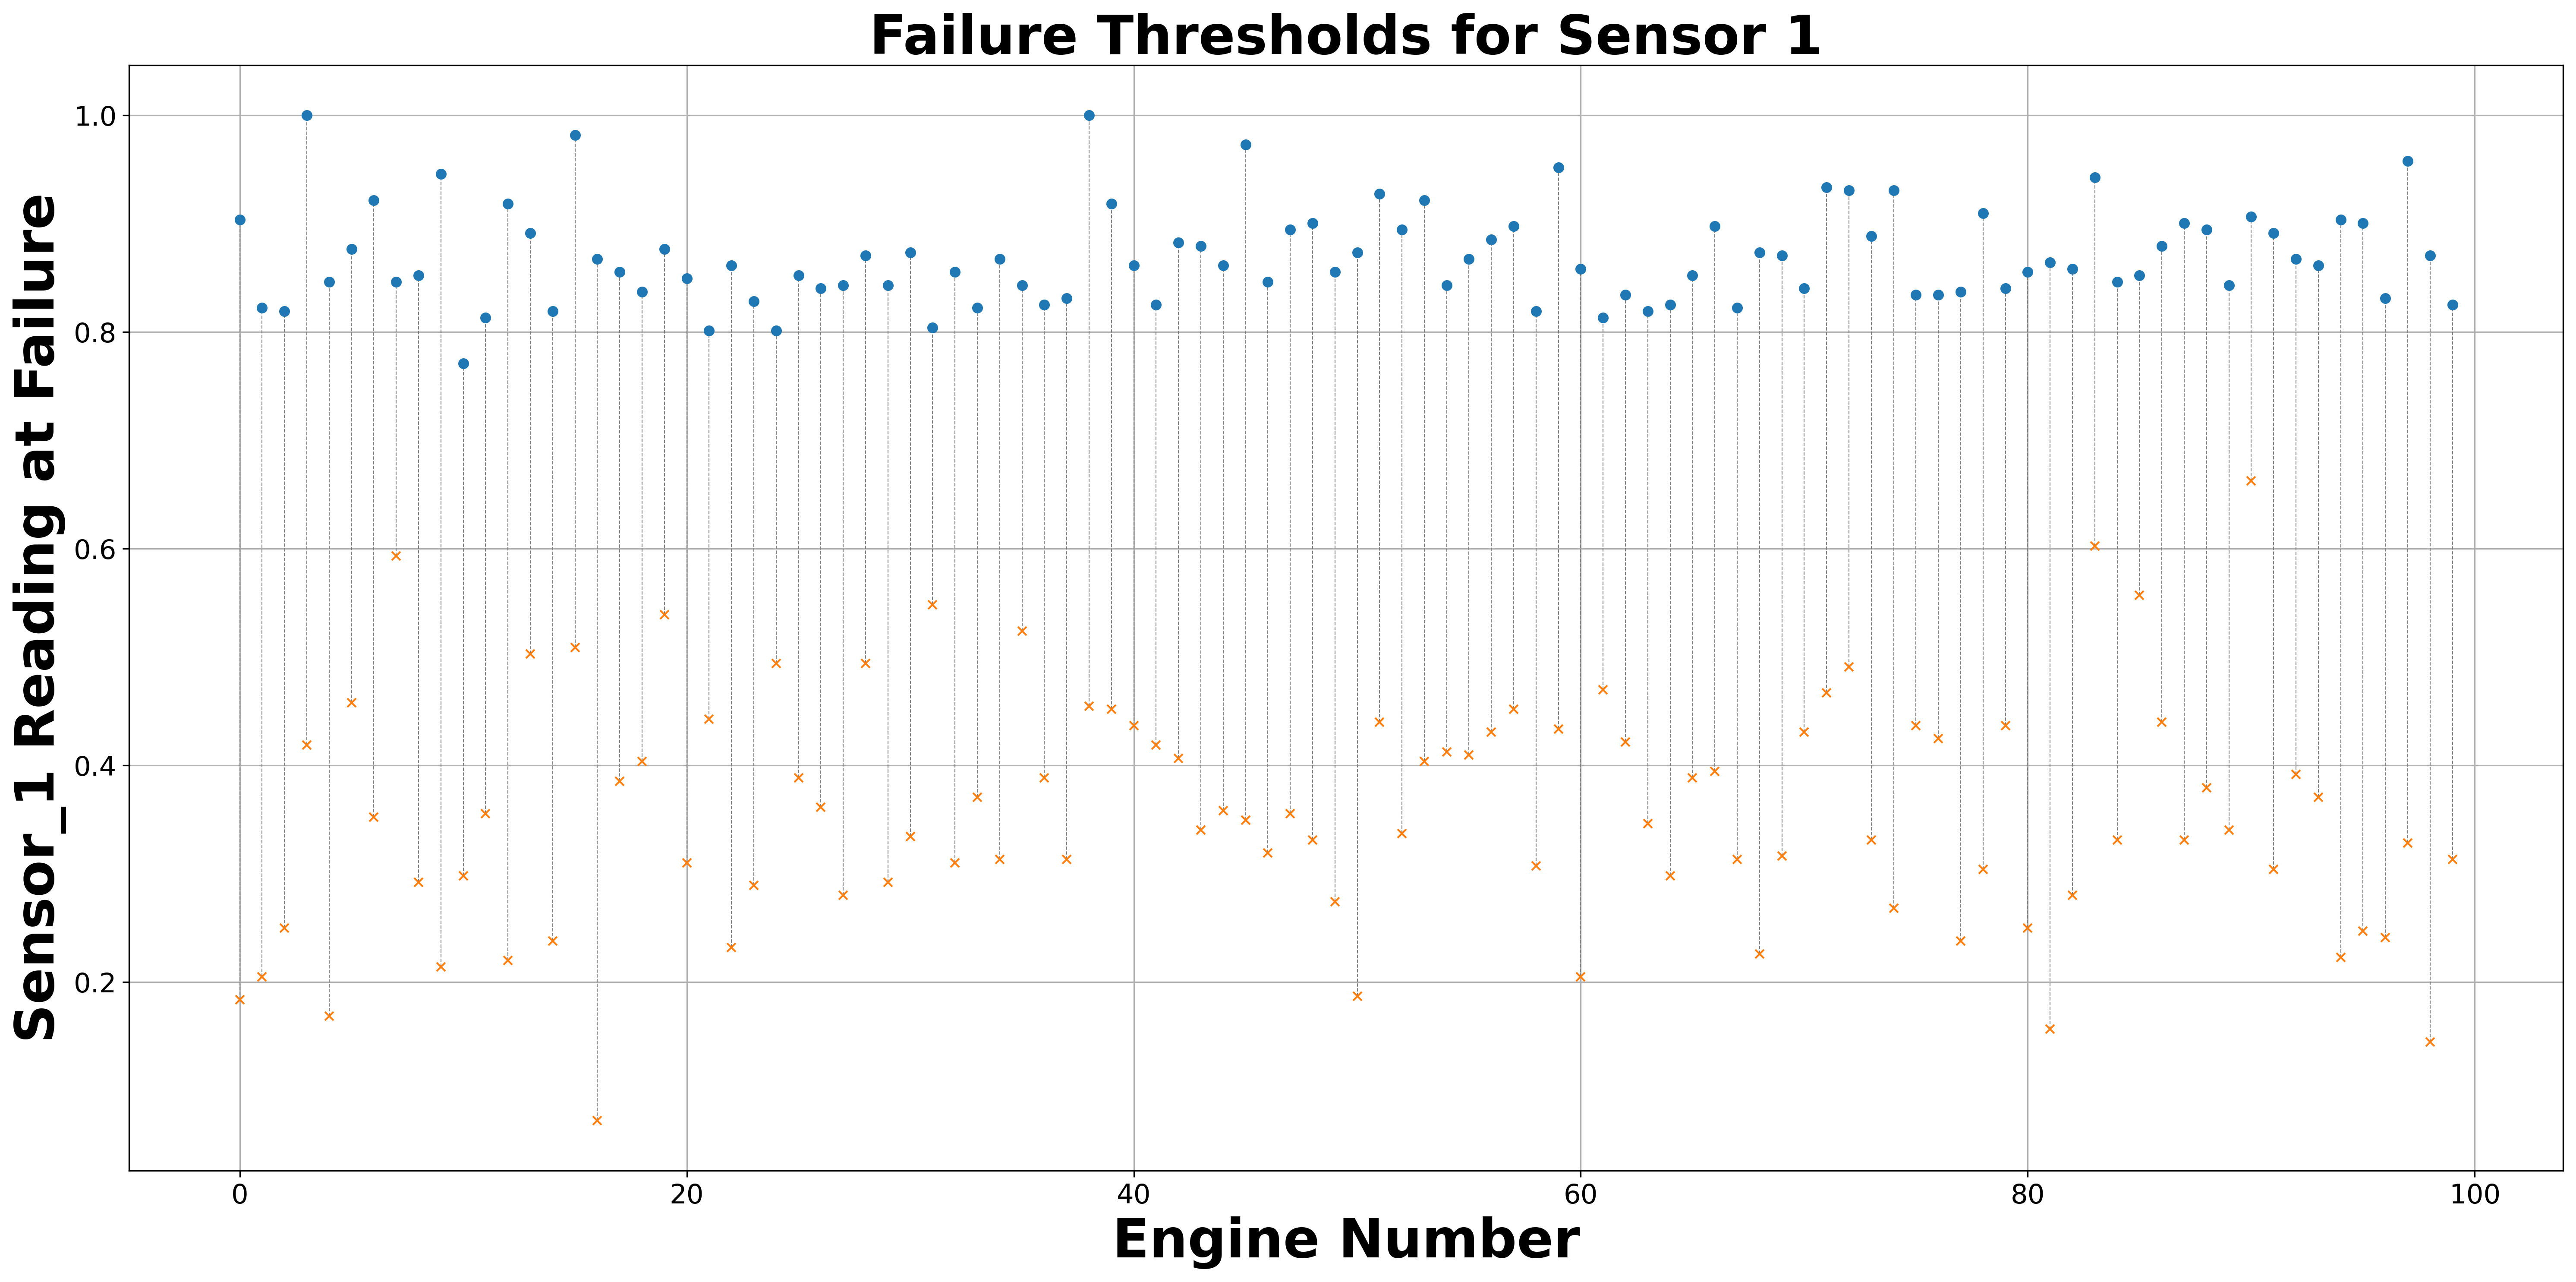

In [53]:
failure_thresholds = []
starts = []
range_of_failure = 20
sensor = 0
for engine in Data:
    dummy = []
    for j in range(1, range_of_failure+1):
        dummy.append(engine[-j][sensor])
    failure_thresholds.append(max(dummy))
    starts.append(engine[0][sensor])
plt.figure(figsize=(20,10), dpi=300)
# Draw a line between each start and failure point
for i in range(len(failure_thresholds)):
    plt.plot([i, i], [starts[i], failure_thresholds[i]], color='gray', linestyle='--', linewidth=0.5)
plt.plot(failure_thresholds, marker='o', linestyle='', markersize=5)
plt.plot(starts, marker='x', linestyle='', markersize=5)
plt.title(f"Failure Thresholds for Sensor {sensor+1}",fontweight='bold',size=30)
plt.xlabel('Engine Number',fontweight='bold',size=30)
plt.xticks(size=15)
plt.ylabel(f'Sensor_{sensor+1} Reading at Failure',fontweight='bold',size=30)
plt.yticks(size=15)
plt.grid(True)
plt.tight_layout()
# plt.savefig(f'Sensor_{sensor+1}_Failure_Thresholds.png')
plt.show()

## Time Depencendy Exploration